# plot paired pseudobulk deg analysis results
- compare the last pre-conversion timepoint and the conversion timepoint
- AIFI L3 deep clean certPro
- paired analysis by deseq2

In [11]:
# load library
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("data.table")
quiet_library("ggpubr")
quiet_library("ggthemes")
quiet_library("SingleCellExperiment")

Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.4.2”


In [2]:
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/paired"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired"

if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))

proj_name <- "ALTRA_AIM3_scRNA_Pseudobulk_paired_"

In [3]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)

cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
options(repr.plot.width = 20, repr.plot.height = 15)

In [4]:
# define subject_colors
subj_colors_list <- read_csv(
  file.path(
    meta_path,
    "ALTRA_longtidunal_subject_colors.csv"
  ),
  show_col_types = FALSE
)
subject_colors <- c(subj_colors_list$subj_colors)
names(subject_colors) <- subj_colors_list$subject.subjectGuid

scale_color_subj <- function(colors = subject_colors, ...) {
  ggplot2:::manual_scale(
    "color",
    values = colors,
    ...
  )
}

In [5]:
source("/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r")

# plot the deg gene expression

In [7]:
pair_sample <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired/ALTRA_AIM3_scRNA_Pseudobulk_paired_paired_samples_info.csv")
pair_sample %>% head()

Rows: 22 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): subject.subjectGuid, sample.sampleKitGuid, file.batchID, sample.di...
dbl  (2): days_to_conversion, pair_number
dttm (1): sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,file.batchID,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion,pair_number,status
<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
CU1003,2021-02-01,KT00493,B176,Rheumatoid arthritis,pre,-127,2,pre_conv
CU1003,2021-06-01,KT02135,B087,Rheumatoid arthritis,conversion,0,2,conversion
CU1010,2022-09-01,KT04474,B178,Rheumatoid arthritis,pre,-102,2,pre_conv
CU1010,2023-01-01,KT04108,B164,CCP3+ At Risk for RA,conversion,0,2,conversion
CU1021,2022-08-01,KT04105,B140,Rheumatoid arthritis,pre,-107,2,pre_conv
CU1021,2022-11-01,KT04462,B158,Rheumatoid arthritis,conversion,0,2,conversion


In [8]:
# load the input deseq2 normalized data to run the model
aim3_pb_deseq <- readRDS(file.path(data_path, "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__deseq2_norm_counts_list.rds"))

In [9]:
# load deg at conversion
aim3_conv_deg <- fread("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired/ALTRA_AIM3_scRNA_Pseudobulk_paired_deseq2_deg_list.csv")
aim3_conv_deg_sig <- aim3_conv_deg %>% filter(q_values < 0.05 | (cell_type == "IL1B+ CD14 monocyte" & gene == "TNF"))
aim3_conv_deg_sig

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD95 memory B cell,IGHA1,117.14997,0.8593125,0.2106638,4.079070,4.521629e-05,3.544957e-02,3.544957e-02,*
CD95 memory B cell,JCHAIN,275.60640,1.4062320,0.2070190,6.792766,1.100034e-11,2.587281e-08,2.587281e-08,*
CD95 memory B cell,LGALS1,58.52746,1.4444447,0.2447936,5.900665,3.620402e-09,4.257592e-06,4.257592e-06,*
Core CD16 monocyte,TNF,42.47443,0.7854057,0.1733217,4.531490,5.856902e-06,4.477016e-02,4.477016e-02,*
IL1B+ CD14 monocyte,TNF,19.43039,0.9117826,0.7762203,1.174644,2.401372e-01,9.997020e-01,9.997020e-01,ns
ISG+ CD16 monocyte,CXCL10,19.32169,2.8217265,0.6024406,4.683825,2.815699e-06,1.254675e-02,1.254675e-02,*
Proliferating T cell,GZMB,40.08333,-1.4919887,0.2999942,-4.973392,6.579138e-07,1.288195e-03,1.288195e-03,*
Proliferating T cell,NKG7,203.24157,-1.0134948,0.1760689,-5.756239,8.600870e-09,3.368101e-05,3.368101e-05,*


In [12]:
# get gene expression longitudinal for the deg changes at conversion
gex_lg <- GetExprsSE(deg_list = aim3_conv_deg_sig, SE_list = aim3_pb_deseq, assay = "vst") %>%
  mutate(Sex = subject.biologicalSex)
# get gene expression at pre post conversion points for the deg changes at conversion
gex_conv <- gex_lg %>%
  filter(sample.sampleKitGuid %in% pair_sample$sample.sampleKitGuid) %>%
  select(-status) %>%
  left_join(select(ungroup(pair_sample), c(sample.sampleKitGuid, status)), by = "sample.sampleKitGuid") %>%
  mutate(status = factor(recode(status, "pre_conv" = "Pre-clinical RA", "conversion" = "Clinical RA"),
    levels = c("Pre-clinical RA", "Clinical RA")
  ))
gex_conv %>% head()

index,batch_id,hto_barcode,hto_category,pbmc_sample_id,pool_id,sample.sampleKitGuid,cohort.cohortGuid,subject.subjectGuid,subject.biologicalSex,⋯,bmi_conv,file.batchID,psbulk_n_cells,psbulk_counts,cell_type,gene,normalized_counts,celltype_gene,Sex,status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<fct>
KT00103_CD95 memory B cell,B046,ATTGACCCGCGTTAG,singlet,PB00103-01,B046-P2,KT00103,SD1,SD1003,Female,⋯,25.65487,B046,26,255496,CD95 memory B cell,IGHA1,7.035490,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00105_CD95 memory B cell,B070,CAGTAGTCACGGTCA,singlet,PB00105-01,B070-P2,KT00105,SD1,SD1007,Female,⋯,26.02500,B070,37,366580,CD95 memory B cell,IGHA1,6.389852,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00109_CD95 memory B cell,B046,CAGTAGTCACGGTCA,singlet,PB00109-01,B046-P2,KT00109,SD1,SD1003,Female,⋯,25.65487,B046,17,204983,CD95 memory B cell,IGHA1,7.361373,CD95 memory B cell: IGHA1,Female,Clinical RA
KT00493_CD95 memory B cell,B176,CTCCTCTGCAATTAC,singlet,PB00493-02,B176-P1,KT00493,CU1,CU1003,Female,⋯,23.14306,B176,12,117753,CD95 memory B cell,IGHA1,6.617786,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00500_CD95 memory B cell,B176,AGTAAGTTCAGCGTA,singlet,PB00500-02,B176-P1,KT00500,CU1,CU1029,Female,⋯,28.67547,B176,14,142158,CD95 memory B cell,IGHA1,6.467002,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00790_CD95 memory B cell,B088,CAGTAGTCACGGTCA,singlet,PB00790-01,B088-P1,KT00790,SD1,SD1007,Female,⋯,26.02500,B088,17,169552,CD95 memory B cell,IGHA1,6.149014,CD95 memory B cell: IGHA1,Female,Clinical RA


### Output table S26 gene expression data

In [13]:
# get the normalized gene counts
pair_deg_exprs <- gex_conv %>%
  select(
    sample.sampleKitGuid, subject.subjectGuid,
    Sex, status, cell_type, gene, celltype_gene, normalized_counts
  ) %>%
  filter(celltype_gene %in% c(
    "Core CD16 monocyte: TNF", "ISG+ CD16 monocyte: CXCL10",
    "CD95 memory B cell: IGHA1", "CD95 memory B cell: JCHAIN", "IL1B+ CD14 monocyte: TNF"
  )) %>%
  arrange(celltype_gene, subject.subjectGuid, status) %>%
  group_by(celltype_gene, subject.subjectGuid) %>%
  mutate(pair_samples = n_distinct(sample.sampleKitGuid)) %>%
  filter(pair_samples == 2) %>%
  ungroup() %>%
  select(-pair_samples)

### plot fig 2F

In [14]:
# define the function
pairViolinPlot <- function(gex, celltype_plot, gene_plot, group_colors) {
  gex_fl <- gex %>%
    filter(cell_type == celltype_plot & gene == gene_plot)
  pair_nums <- gex_fl %>%
    group_by(subject.subjectGuid) %>%
    tally()
  pair_subs <- pair_nums %>%
    filter(n >= 2) %>%
    pull(subject.subjectGuid) %>%
    unique()
  p1 <- gex_fl %>%
    filter(subject.subjectGuid %in% pair_subs) %>%
    ggplot(aes(x = status, y = normalized_counts)) +
    geom_violin(aes(color = status)) +
    geom_point(aes(group = subject.subjectGuid, shape = Sex), color = "grey", size = 1.5) +
    geom_line(aes(group = subject.subjectGuid), color = "grey") +
    labs(title = paste0(celltype_plot, "\n", gene_plot), x = "", y = "Normalized expression") +
    scale_color_manual(values = group_colors[2:3]) +
    theme_classic() +
    theme(
      text = element_text(size = 10, face = "bold"),
      axis.title = element_text(size = 10, face = "bold"),
      axis.text = element_text(size = 10, face = "bold"),
      plot.title = element_text(size = 10, face = "bold"),
      axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
      legend.position = "none"
    ) +
    # scale_shape_manual(values = c(16, 2)) +
    guides(color = FALSE, fill = FALSE)

  ggsave(
    file.path(fig_path, paste0(
      proj_name, celltype_plot,
      "_", gene_plot, "_paired_expression.pdf"
    )),
    width = 2.66 * 2, height = 4.35 * 2, units = "cm", dpi = 300
  )
  return(p1)
}

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


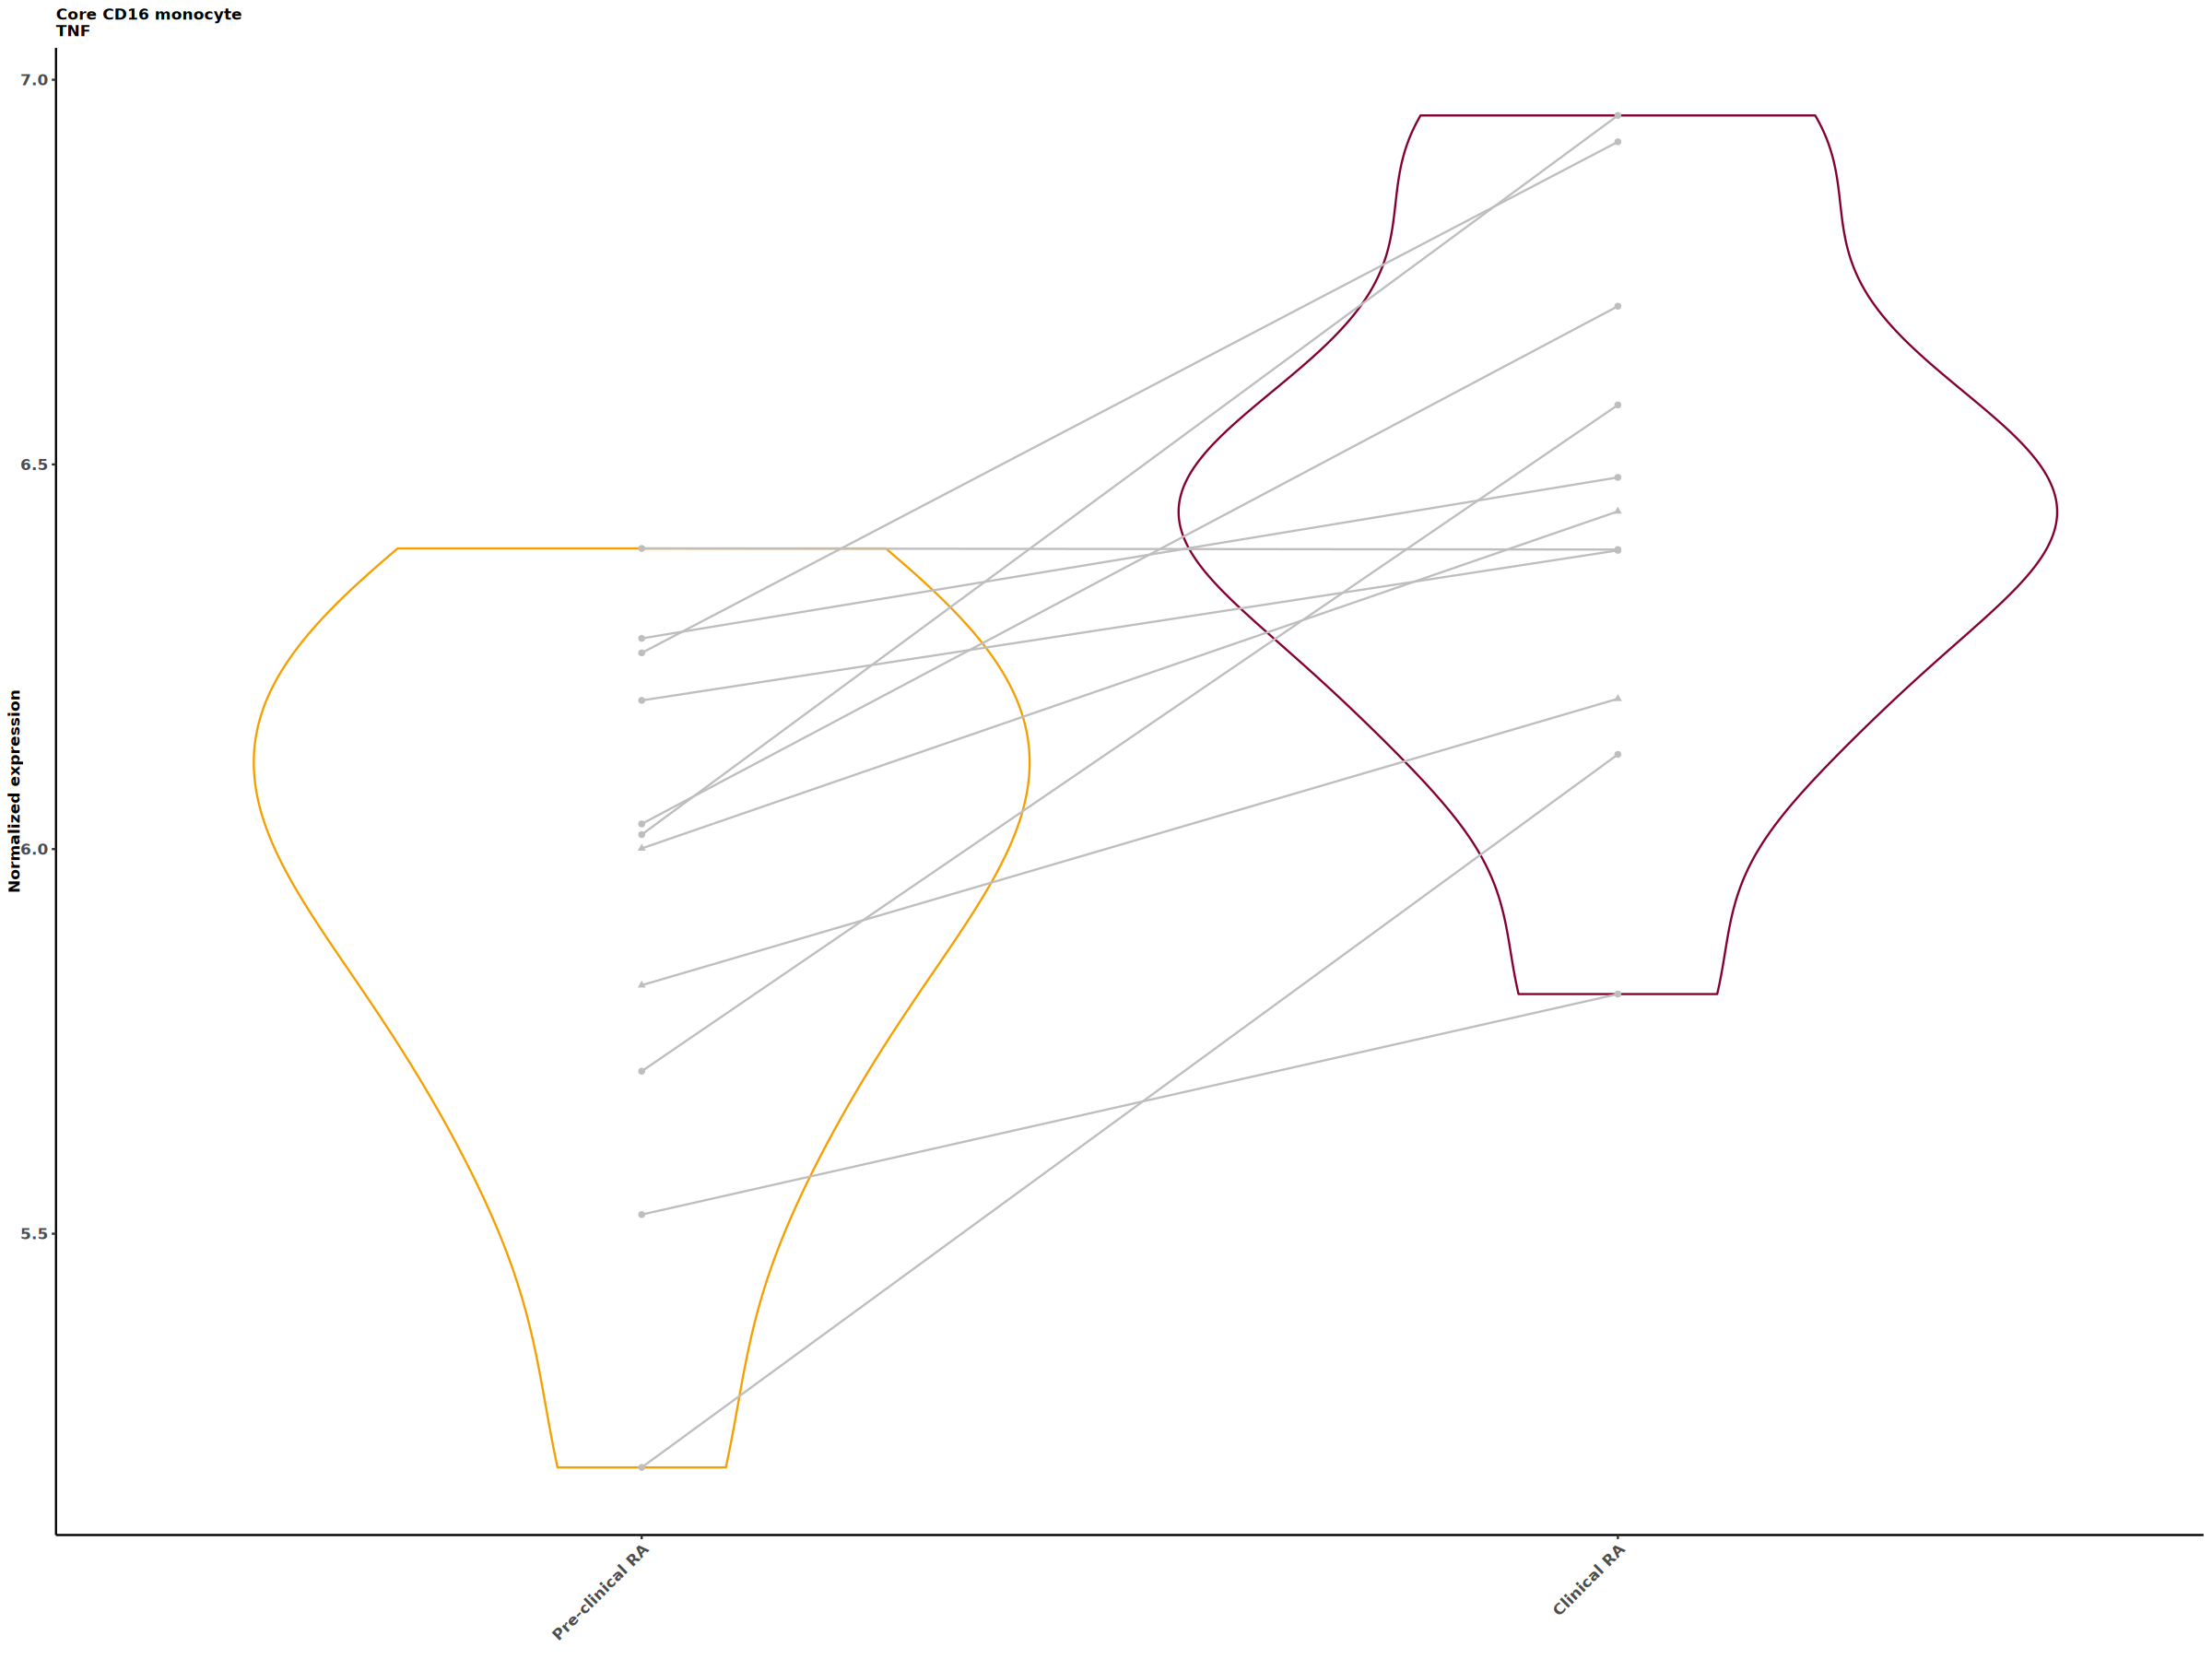

In [15]:
pairViolinPlot(gex_conv, "Core CD16 monocyte", "TNF", group_colors = ari_colors)

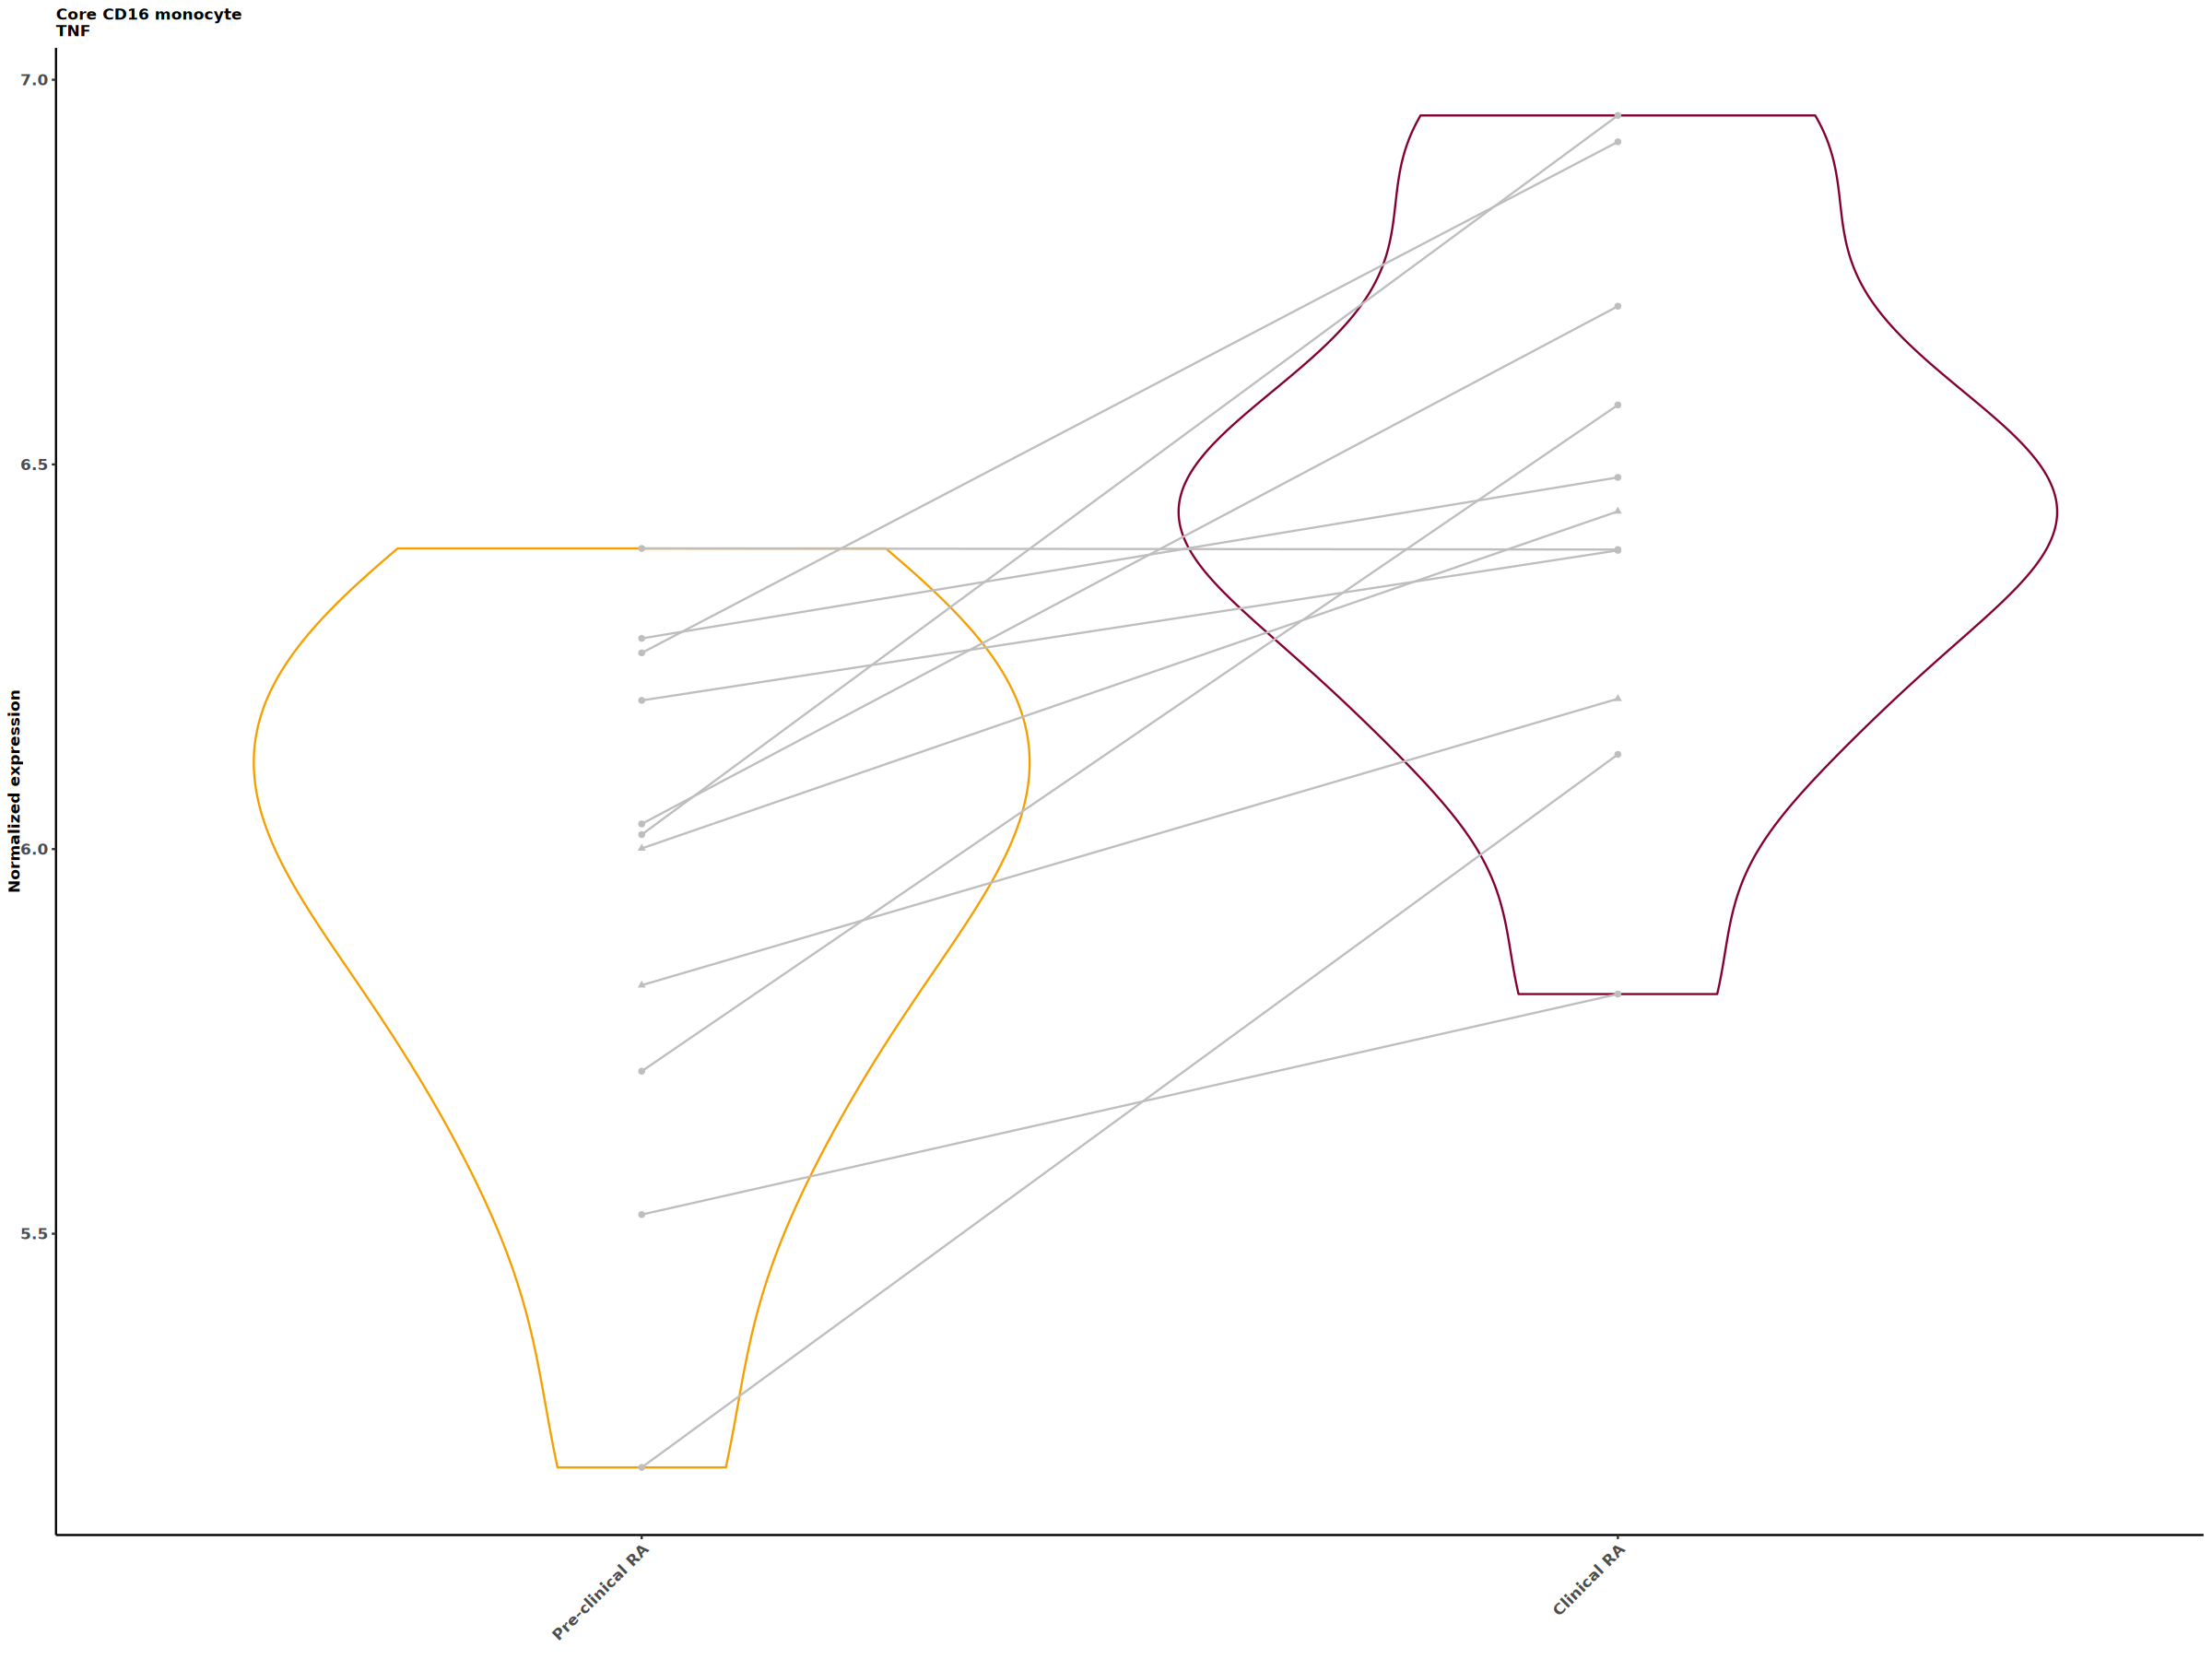

In [16]:
pairViolinPlot(gex_conv, "Core CD16 monocyte", "TNF", group_colors = ari_colors)

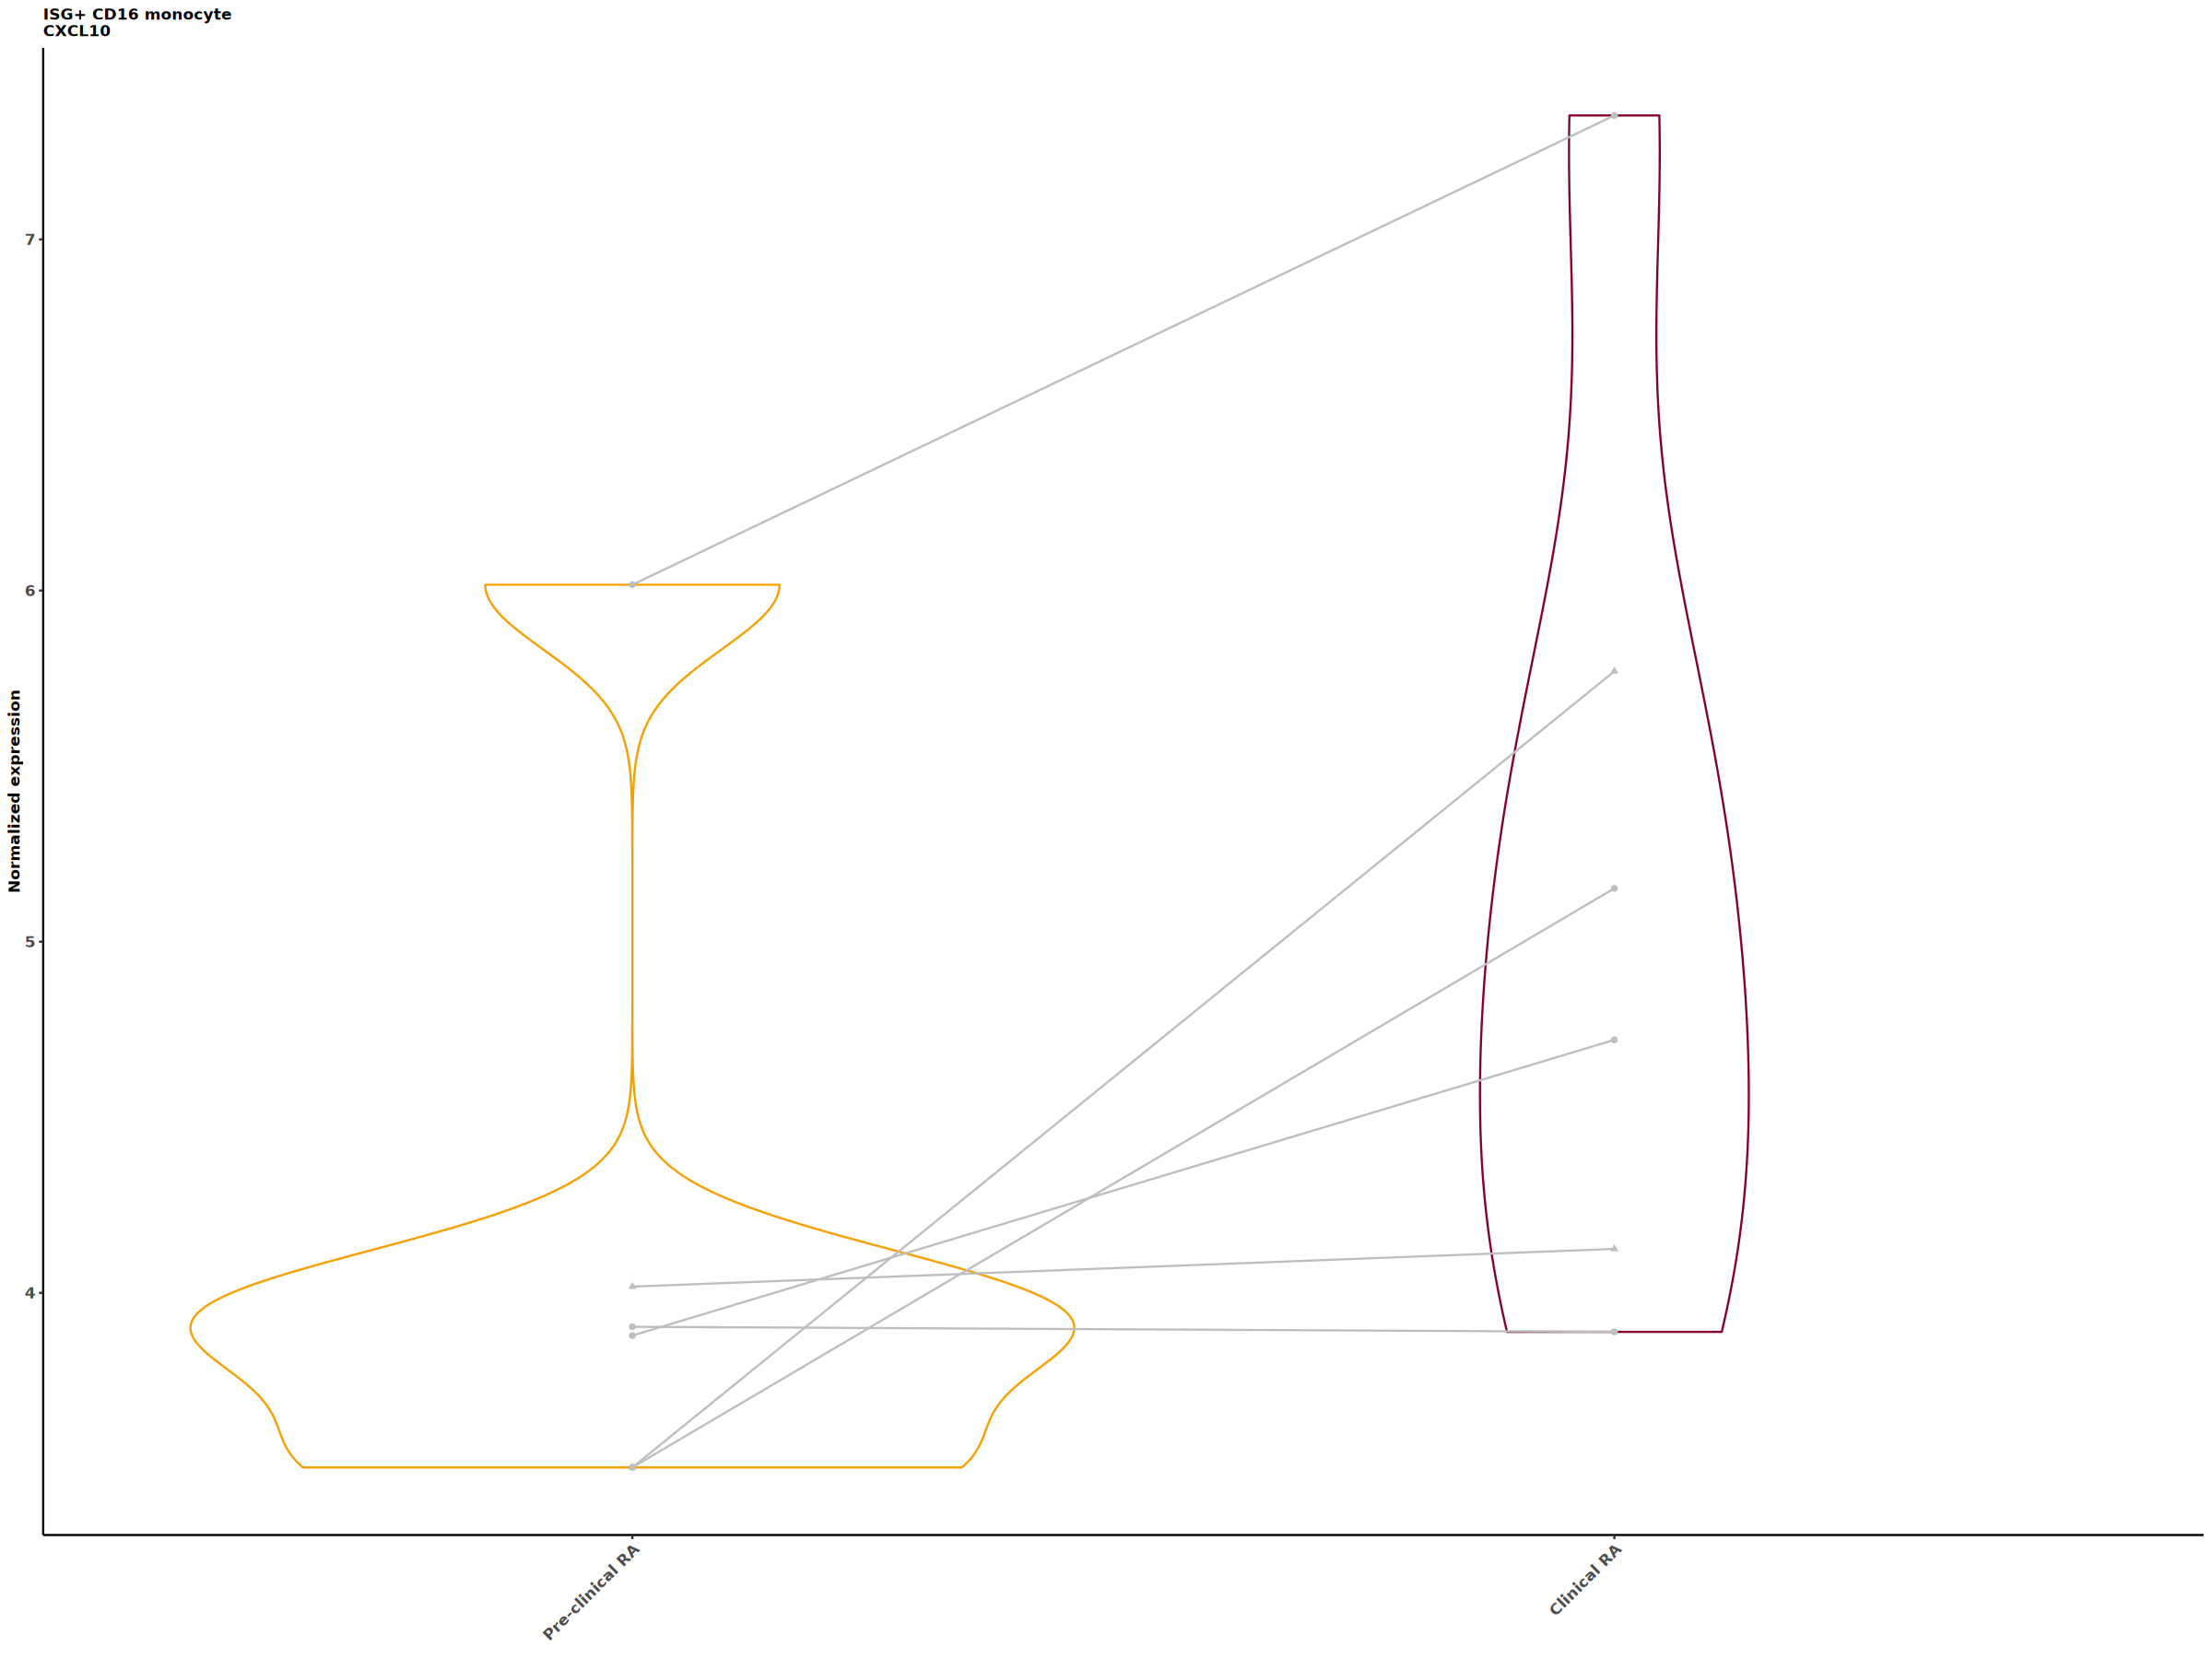

In [17]:
pairViolinPlot(gex_conv, "ISG+ CD16 monocyte", "CXCL10", group_colors = ari_colors)

### plot S5G

In [18]:
# define the function
pairViolinPlotFacet <- function(gex, celltype_plot, genes_plot, group_colors) {
  gex_fl <- gex %>%
    filter(cell_type == celltype_plot & gene %in% genes_plot)
  pair_nums <- gex_fl %>%
    distinct(sample.sampleKitGuid, .keep_all = TRUE) %>%
    group_by(subject.subjectGuid) %>%
    tally()
  pair_subs <- pair_nums %>%
    filter(n >= 2) %>%
    pull(subject.subjectGuid) %>%
    unique()
  p1 <- gex_fl %>%
    filter(subject.subjectGuid %in% pair_subs) %>%
    ggplot(aes(x = status, y = normalized_counts)) +
    geom_violin(aes(color = status)) +
    geom_point(aes(group = subject.subjectGuid, shape = Sex), color = "grey", size = 1.5) +
    geom_line(aes(group = subject.subjectGuid), color = "grey") +
    labs(title = paste0(celltype_plot), x = "", y = "Normalized expression") +
    scale_color_manual(values = group_colors[2:3]) +
    theme_classic() +
    facet_wrap(vars(gene), scales = "free_y") +
    theme(
      text = element_text(size = 10, face = "bold"),
      axis.title = element_text(size = 10, face = "bold"),
      axis.text = element_text(size = 10, face = "bold"),
      plot.title = element_text(size = 10, face = "bold"),
      axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
      legend.position = "none"
    ) +
    # scale_shape_manual(values = c(1, 2)) +
    guides(color = FALSE, fill = FALSE)

  ggsave(
    file.path(fig_path, paste0(
      proj_name, celltype_plot,
      "_paired_expression.pdf"
    )),
    width = 6, height = 3
  )
  return(p1)
}

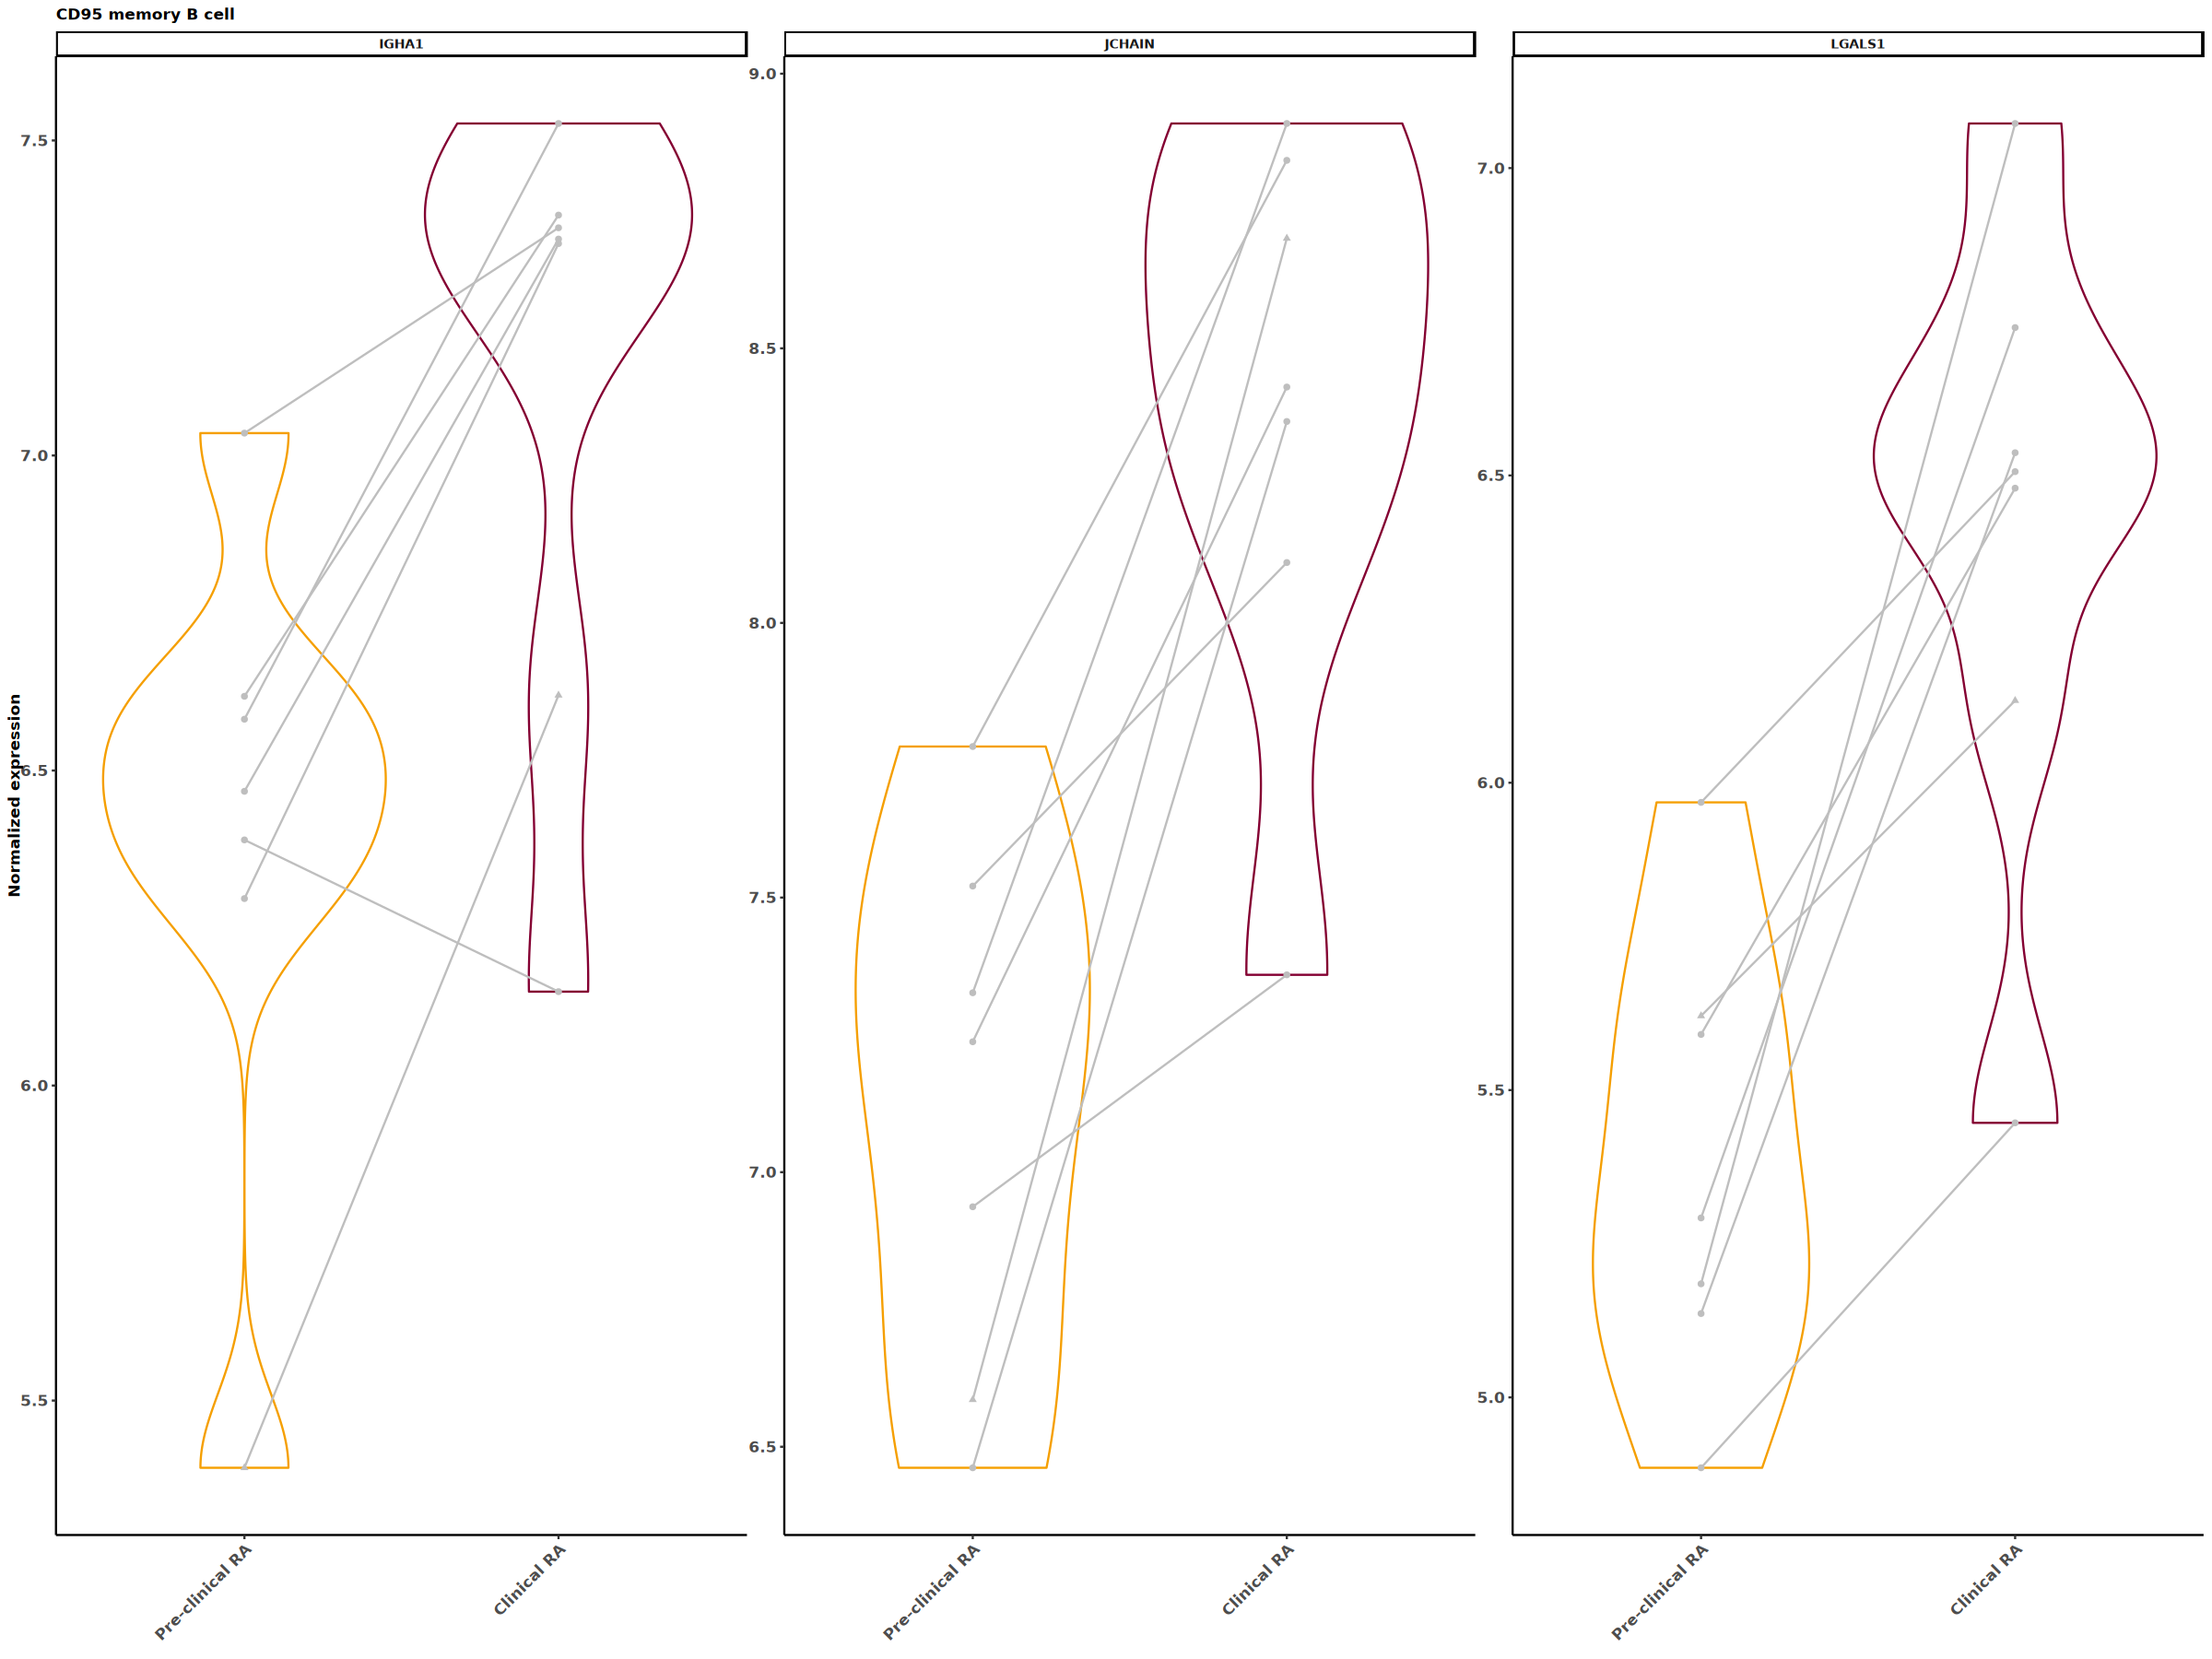

In [19]:
pairViolinPlotFacet(gex_conv, "CD95 memory B cell", c("IGHA1", "JCHAIN", "LGALS1"), group_colors = ari_colors)

In [20]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] SingleCellExperiment_1.28.0 SummarizedExperiment_1.36.0
 [3] Biobase_2.66.0              GenomicRanges_1.58.0       
 [5] GenomeInfoDb_1.42.0         IRanges_2.40.0             
 [7] S4Vectors_0.44.0            BiocGenerics_0.52.0        
 [9] MatrixGenerics_1.18.0       matrixStats_1.5.0          
[1